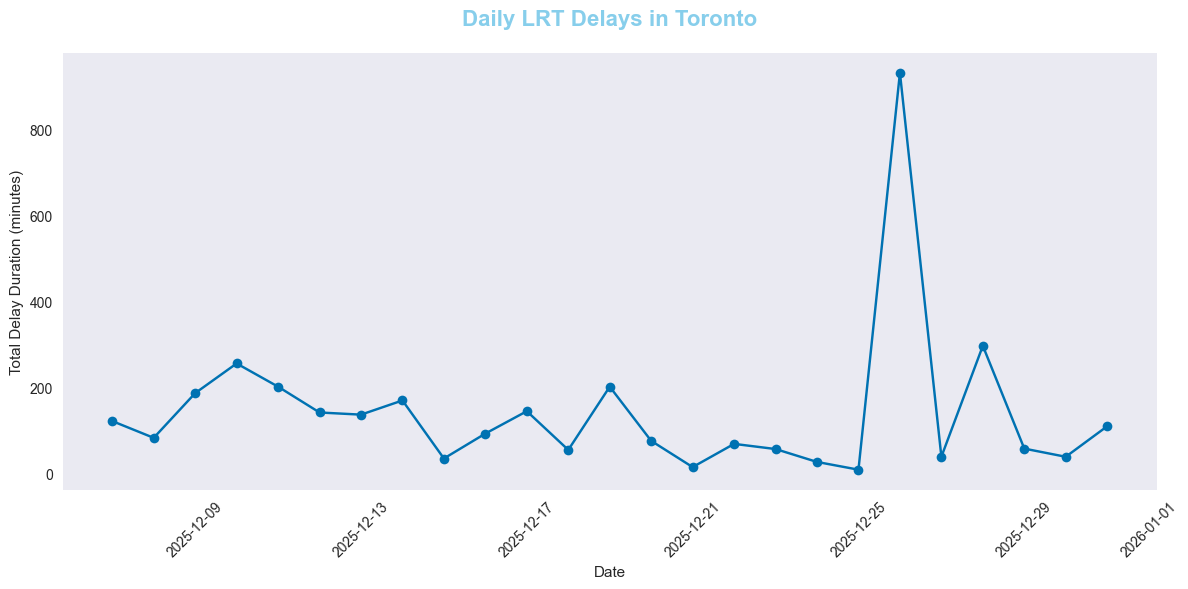

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
# Fetch the CSV data from the URL
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/d4d64b0e-2945-4c92-960e-f0103ad48b02/resource/9a800c92-0362-4cee-8232-7374596b6a43/download/TTC%20LRT%20Delays.csv"
response = requests.get(url)
response.raise_for_status()  # Check if the request was successful
# Read the CSV data into a pandas DataFrame
ttc_data = StringIO(response.text)
df = pd.read_csv(ttc_data)
# Display the first few rows of the DataFrame
#print(df.head())
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
# Convert the 'Delay Duration (minutes)' column to numeric format
df['Min Delay'] = pd.to_numeric(df['Min Delay'], errors='coerce')
# Drop rows with no date or delay duration
df.dropna(subset=['Date', 'Min Delay'], inplace=True)
# Group the data by date and sum the delay durations
daily_delays = df.groupby('Date')['Min Delay'].sum().reset_index()
# Plot the daily delays over time
plt.style.use('seaborn-v0_8-colorblind')
plt.figure(figsize=(12, 6))
plt.plot(daily_delays['Date'], daily_delays['Min Delay'], marker='o')
plt.title('Daily LRT Delays in Toronto',
          color='skyblue',
          fontweight='bold',
          fontsize=16,
          pad=20)
plt.xlabel('Date')
plt.ylabel('Total Delay Duration (minutes)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show() 

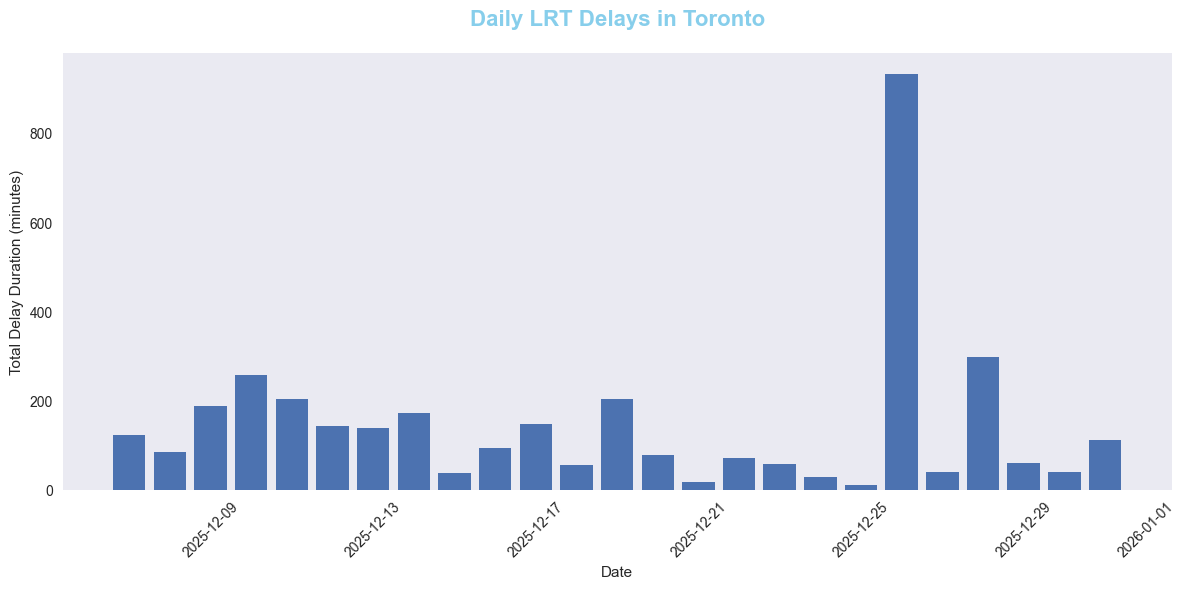

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(daily_delays['Date'], daily_delays['Min Delay'])
plt.title('Daily LRT Delays in Toronto',
          color='skyblue',
          fontweight='bold',
          fontsize=16,
          pad=20)
plt.xlabel('Date')
plt.ylabel('Total Delay Duration (minutes)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show() 